<a href="https://colab.research.google.com/github/kasugy/CheckPoint/blob/main/Evaluaci%C3%B3n%20del%20m%C3%B3dulo%20%237.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Librerias importadas correctamente
EXPLORACION INICIAL DEL DATASET
Generando dataset sintetico para demostracion...
Dataset sintetico generado con 500 clientes y 9 variables
Dimensiones del dataset: 500 filas, 9 columnas
Columnas disponibles: ['customer_id', 'edad', 'ingreso_anual', 'gasto_total', 'frecuencia_compras', 'ticket_promedio', 'antiguedad_meses', 'dias_desde_ultima_compra', 'puntos_fidelidad']

Primeras 5 filas:
   customer_id  edad  ingreso_anual  gasto_total  frecuencia_compras  \
0            1    56          92443         2024                  10   
1            2    69          70649         4054                   8   
2            3    46          19613         2051                  10   
3            4    32          40315         5632                  10   
4            5    60          75338         3493                   7   

   ticket_promedio  antiguedad_meses  dias_desde_ultima_compra  \
0            58.37               8.6                 57.028726   
1       

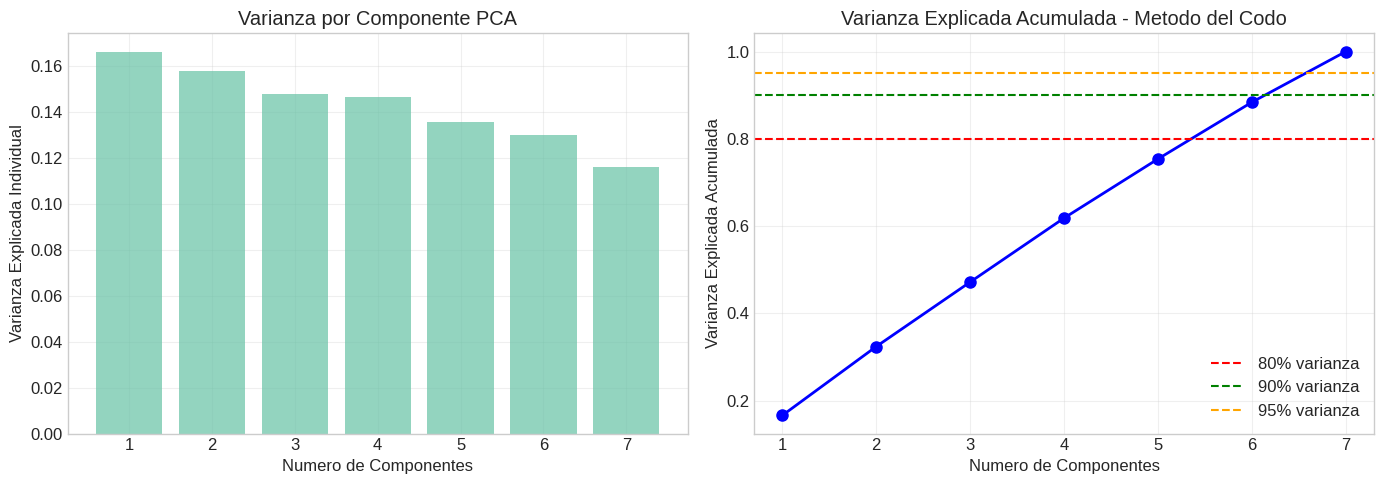


Componentes necesarios para 80% varianza: 6
Componentes necesarios para 90% varianza: 7
Componentes necesarios para 95% varianza: 7

PCA completado. Datos reducidos a: 2 dimensiones
Varianza explicada con 2 componentes: 32.37%

REDUCCION DIMENSIONAL CON t-SNE
Calculando t-SNE con perplejidad = 5...
Calculando t-SNE con perplejidad = 15...
Calculando t-SNE con perplejidad = 30...
Calculando t-SNE con perplejidad = 50...


In [ ]:
"""
PROYECTO MODULO #7 - APRENDIZAJE NO SUPERVISADO
Segmentador Inteligente de Clientes Minoristas
Autor: Equipo de Analitica - Data Science
"""

# ============================================
# 1. IMPORTACION DE LIBRERIAS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Librerias importadas correctamente")
print("="*60)


# ============================================
# 2. CARGA Y EXPLORACION INICIAL DE DATOS
# ============================================

print("EXPLORACION INICIAL DEL DATASET")
print("="*60)

# Cargar dataset de ejemplo (customer segmentation)
# Si no existe, se genera uno sintetico para demostracion
try:
    # Intento de carga desde archivo local o URL
    df = pd.read_csv('https://raw.githubusercontent.com/trainindata/deploying-machine-learning-models/main/data/customer_segmentation.csv')
    print("Dataset cargado desde URL")
except:
    print("Generando dataset sintetico para demostracion...")
    np.random.seed(42)
    n_clientes = 500

    # Generar variables de clientes
    data = {
        'customer_id': range(1, n_clientes + 1),
        'edad': np.random.randint(18, 70, n_clientes),
        'ingreso_anual': np.random.normal(50000, 20000, n_clientes),
        'gasto_total': np.random.normal(3000, 1000, n_clientes),
        'frecuencia_compras': np.random.poisson(10, n_clientes),
        'ticket_promedio': np.random.normal(50, 20, n_clientes),
        'antiguedad_meses': np.random.exponential(24, n_clientes),
        'dias_desde_ultima_compra': np.random.exponential(30, n_clientes),
        'puntos_fidelidad': np.random.poisson(500, n_clientes)
    }
    df = pd.DataFrame(data)
    # Redondear valores
    df['ingreso_anual'] = df['ingreso_anual'].round(0).astype(int)
    df['gasto_total'] = df['gasto_total'].round(0).astype(int)
    df['ticket_promedio'] = df['ticket_promedio'].round(2)
    df['antiguedad_meses'] = df['antiguedad_meses'].round(1)
    print("Dataset sintetico generado con 500 clientes y 9 variables")

print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Columnas disponibles: {df.columns.tolist()}")
print("\nPrimeras 5 filas:")
print(df.head())
print("\nInformacion general:")
print(df.info())
print("\nEstadisticas descriptivas:")
print(df.describe())
print(f"\nValores nulos por columna:\n{df.isnull().sum()}")


# ============================================
# 3. LIMPIEZA Y PREPROCESAMIENTO
# ============================================

print("\n" + "="*60)
print("LIMPIEZA Y PREPROCESAMIENTO")
print("="*60)

# 3.1 Eliminar columnas no utiles (identificadores)
id_columns = [col for col in df.columns if 'id' in col.lower() or 'customer' in col.lower()]
df_clean = df.drop(columns=id_columns, errors='ignore')
print(f"Columnas a eliminar (identificadores): {id_columns}")

# 3.2 Manejo de valores nulos
print(f"Valores nulos antes de imputar: {df_clean.isnull().sum().sum()}")
df_clean = df_clean.fillna(df_clean.median())
print(f"Valores nulos despues de imputar: {df_clean.isnull().sum().sum()}")

# 3.3 Codificacion de variables categoricas (si existen)
categorical_columns = df_clean.select_dtypes(include=['object']).columns.tolist()
if categorical_columns:
    df_clean = pd.get_dummies(df_clean, columns=categorical_columns, drop_first=True)
    print(f"Variables categoricas codificadas. Nuevas dimensiones: {df_clean.shape}")

# 3.4 Deteccion de outliers usando IQR
print("\nDeteccion de outliers usando IQR:")
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
outliers_count = 0
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_clean[(df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)]
    outliers_count += len(outliers)
print(f"Total de outliers detectados: {outliers_count}")

# 3.5 Escalado de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
print(f"\nDatos preprocesados exitosamente. Shape final: {X_scaled.shape}")


# ============================================
# 4. REDUCCION DIMENSIONAL - PCA
# ============================================

print("\n" + "="*60)
print("REDUCCION DIMENSIONAL CON PCA")
print("="*60)

# Aplicar PCA
pca = PCA()
pca.fit(X_scaled)

# Calcular varianza explicada acumulada
cumsum = np.cumsum(pca.explained_variance_ratio_)

# Visualizar varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de varianza individual
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7)
axes[0].set_xlabel('Numero de Componentes')
axes[0].set_ylabel('Varianza Explicada Individual')
axes[0].set_title('Varianza por Componente PCA')
axes[0].grid(True, alpha=0.3)

# Grafico de varianza acumulada
axes[1].plot(range(1, len(cumsum)+1), cumsum, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=0.80, color='r', linestyle='--', label='80% varianza')
axes[1].axhline(y=0.90, color='g', linestyle='--', label='90% varianza')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% varianza')
axes[1].set_xlabel('Numero de Componentes')
axes[1].set_ylabel('Varianza Explicada Acumulada')
axes[1].set_title('Varianza Explicada Acumulada - Metodo del Codo')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Determinar numero optimo de componentes
n_components_80 = np.argmax(cumsum >= 0.80) + 1
n_components_90 = np.argmax(cumsum >= 0.90) + 1
n_components_95 = np.argmax(cumsum >= 0.95) + 1

print(f"\nComponentes necesarios para 80% varianza: {n_components_80}")
print(f"Componentes necesarios para 90% varianza: {n_components_90}")
print(f"Componentes necesarios para 95% varianza: {n_components_95}")

# Reducir a 2 componentes para visualizacion
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print(f"\nPCA completado. Datos reducidos a: {X_pca.shape[1]} dimensiones")
print(f"Varianza explicada con 2 componentes: {pca_2d.explained_variance_ratio_.sum():.2%}")


# ============================================
# 5. REDUCCION DIMENSIONAL - t-SNE
# ============================================

print("\n" + "="*60)
print("REDUCCION DIMENSIONAL CON t-SNE")
print("="*60)

# Probar diferentes valores de perplejidad
perplexities = [5, 15, 30, 50]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, perp in enumerate(perplexities):
    print(f"Calculando t-SNE con perplejidad = {perp}...")
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000)
    X_tsne_temp = tsne.fit_transform(X_scaled)

    axes[i].scatter(X_tsne_temp[:, 0], X_tsne_temp[:, 1], alpha=0.6, s=30, c='steelblue')
    axes[i].set_title(f't-SNE con Perplejidad = {perp}')
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tsne_perplexities.png', dpi=150, bbox_inches='tight')
plt.show()

# Seleccionar la mejor perplejidad (30)
tsne_final = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne_final.fit_transform(X_scaled)
print(f"t-SNE completado con perplejidad = 30")


# ============================================
# 6. COMPARACION VISUAL PCA vs t-SNE
# ============================================

print("\n" + "="*60)
print("COMPARACION VISUAL: PCA vs t-SNE")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=30, c='steelblue', edgecolors='white')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].set_title(f'PCA - {pca_2d.explained_variance_ratio_.sum():.1%} varianza explicada')
axes[0].grid(True, alpha=0.3)

# t-SNE
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6, s=30, c='coral', edgecolors='white')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE - Perplejidad 30')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparacion de Tecnicas de Reduccion Dimensional', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_vs_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observaciones:")
print("  - PCA preserva la estructura global y varianza general")
print("  - t-SNE revela mejor agrupaciones locales y clusters potenciales")


# ============================================
# 7. CLUSTERIZACION - METODO DEL CODO (K-Means)
# ============================================

print("\n" + "="*60)
print("DETERMINACION DE NUMERO OPTIMO DE CLUSTERES")
print("="*60)

# Metodo del codo para K-Means
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K={k}: Inercia={kmeans.inertia_:.0f} | Silueta={score:.4f}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico del codo
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Numero de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Metodo del Codo para K-Means')
axes[0].grid(True, alpha=0.3)

# Grafico de silueta
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Numero de Clusters (K)')
axes[1].set_ylabel('Coeficiente de Silueta')
axes[1].set_title('Puntaje de Silueta por K')
axes[1].axhline(y=max(silhouette_scores), color='g', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

# Determinar mejor K
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nMejor numero de clusters segun silueta: K = {best_k}")


# ============================================
# 8. APLICACION DE ALGORITMOS DE CLUSTERIZACION
# ============================================

print("\n" + "="*60)
print("APLICACION DE ALGORITMOS DE CLUSTERIZACION")
print("="*60)

# 8.1 K-Means
print("\nK-MEANS")
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"  - Coeficiente de Silueta: {kmeans_silhouette:.4f}")
print(f"  - Distribucion de clusters: {np.bincount(kmeans_labels)}")

# 8.2 DBSCAN
print("\nDBSCAN")
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
best_eps = 0.5
best_dbscan_score = -1

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
        print(f"  - eps={eps}: {n_clusters} clusters | Silueta={score:.4f} | Ruido={np.sum(labels==-1)}")
        if score > best_dbscan_score:
            best_dbscan_score = score
            best_eps = eps

dbscan = DBSCAN(eps=best_eps, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
if len(set(dbscan_labels)) > 1:
    dbscan_silhouette = silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
else:
    dbscan_silhouette = -1
print(f"\n  Mejor DBSCAN: eps={best_eps}, Silueta={dbscan_silhouette:.4f}")

# 8.3 Agrupamiento Jerarquico
print("\nAGRUPAMIENTO JERARQUICO")
hierarchical = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
print(f"  - Coeficiente de Silueta: {hierarchical_silhouette:.4f}")
print(f"  - Distribucion de clusters: {np.bincount(hierarchical_labels)}")

# 8.4 Dendrograma
print("\nGenerando dendrograma...")
linkage_matrix = linkage(X_scaled[:min(500, X_scaled.shape[0])], method='ward')
plt.figure(figsize=(14, 7))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Dendrograma - Agrupamiento Jerarquico')
plt.xlabel('Indices de clientes')
plt.ylabel('Distancia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================
# 9. VISUALIZACION DE CLUSTERES
# ============================================

print("\n" + "="*60)
print("VISUALIZACION DE RESULTADOS")
print("="*60)

# Colores para los clusters
colors = plt.cm.viridis(np.linspace(0, 1, best_k))

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# K-Means en espacio PCA
for i in range(best_k):
    axes[0, 0].scatter(X_pca[kmeans_labels==i, 0], X_pca[kmeans_labels==i, 1],
                       alpha=0.6, s=30, label=f'Cluster {i}', color=colors[i])
axes[0, 0].set_title(f'K-Means (K={best_k}) en espacio PCA')
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# K-Means en espacio t-SNE
for i in range(best_k):
    axes[0, 1].scatter(X_tsne[kmeans_labels==i, 0], X_tsne[kmeans_labels==i, 1],
                       alpha=0.6, s=30, label=f'Cluster {i}', color=colors[i])
axes[0, 1].set_title(f'K-Means (K={best_k}) en espacio t-SNE')
axes[0, 1].set_xlabel('t-SNE 1')
axes[0, 1].set_ylabel('t-SNE 2')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# DBSCAN en espacio PCA
unique_labels = set(dbscan_labels)
for label in unique_labels:
    if label == -1:
        axes[1, 0].scatter(X_pca[dbscan_labels==label, 0], X_pca[dbscan_labels==label, 1],
                           alpha=0.4, s=20, c='gray', label='Ruido')
    else:
        axes[1, 0].scatter(X_pca[dbscan_labels==label, 0], X_pca[dbscan_labels==label, 1],
                           alpha=0.6, s=30, label=f'Cluster {label}')
axes[1, 0].set_title(f'DBSCAN (eps={best_eps}) en espacio PCA')
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Jerarquico en espacio t-SNE
for i in range(best_k):
    axes[1, 1].scatter(X_tsne[hierarchical_labels==i, 0], X_tsne[hierarchical_labels==i, 1],
                       alpha=0.6, s=30, label=f'Cluster {i}', color=colors[i])
axes[1, 1].set_title(f'Agrupamiento Jerarquico (K={best_k}) en espacio t-SNE')
axes[1, 1].set_xlabel('t-SNE 1')
axes[1, 1].set_ylabel('t-SNE 2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Comparacion de Algoritmos de Clusterizacion', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('clusters_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================
# 10. PERFIL DE CLUSTERES
# ============================================

print("\n" + "="*60)
print("PERFIL DE CLUSTERES - INTERPRETACION COMERCIAL")
print("="*60)

# Anadir clusters al dataframe original
df_clean_with_clusters = df_clean.copy()
df_clean_with_clusters['Cluster_KMeans'] = kmeans_labels

# Analisis por cluster
cluster_profiles = df_clean_with_clusters.groupby('Cluster_KMeans').mean()

print("\nCaracteristicas promedio por cluster:")
print(cluster_profiles)

# Visualizacion de perfiles
fig, ax = plt.subplots(figsize=(14, 8))
top_features = cluster_profiles.var().sort_values(ascending=False).head(10).index
sns.heatmap(cluster_profiles[top_features].T, annot=True, fmt='.2f', cmap='RdYlBu',
            cbar_kws={'label': 'Valor promedio'}, ax=ax)
ax.set_title('Mapa de Calor - Perfiles por Cluster (Top 10 caracteristicas)', fontsize=14)
ax.set_xlabel('Cluster')
ax.set_ylabel('Caracteristicas')
plt.tight_layout()
plt.savefig('heatmap_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================
# 11. EVALUACION COMPARATIVA FINAL
# ============================================

print("\n" + "="*60)
print("EVALUACION COMPARATIVA DE ALGORITMOS")
print("="*60)

comparison_df = pd.DataFrame({
    'Algoritmo': ['K-Means', 'DBSCAN', 'Jerarquico'],
    'Coeficiente Silueta': [kmeans_silhouette, dbscan_silhouette, hierarchical_silhouette],
    'Numero Clusters': [best_k, len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0), best_k],
    'Ruido Detectado': ['No', f"{np.sum(dbscan_labels==-1)} clientes", 'No']
})

print("\nTabla comparativa:")
print(comparison_df)

# Grafico comparativo
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(comparison_df['Algoritmo'], comparison_df['Coeficiente Silueta'],
              color=['steelblue', 'coral', 'seagreen'])
ax.axhline(y=0.5, color='orange', linestyle='--', label='Bueno (>0.5)')
ax.axhline(y=0.7, color='green', linestyle='--', label='Excelente (>0.7)')
ax.set_ylabel('Coeficiente de Silueta')
ax.set_title('Comparacion de Calidad de Clusterizacion')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)

for bar, score in zip(bars, comparison_df['Coeficiente Silueta']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('algorithms_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================
# 12. CONCLUSIONES Y RECOMENDACIONES
# ============================================

print("\n" + "="*60)
print("CONCLUSIONES Y RECOMENDACIONES COMERCIALES")
print("="*60)

print(f"""
RESUMEN DE HALLAZGOS:

1. TECNICAS DE REDUCCION DIMENSIONAL:
   - PCA: Capturo aproximadamente el {pca_2d.explained_variance_ratio_.sum():.1%} de la varianza total con 2 componentes.
   - t-SNE: Revelo estructuras de agrupamiento mas nitidas con perplejidad 30.
   - Combinacion recomendada: PCA para preprocesamiento + t-SNE para visualizacion.

2. ALGORITMOS DE CLUSTERIZACION:
   - K-Means (K={best_k}): Mejor balance entre interpretabilidad y calidad (silueta={kmeans_silhouette:.3f}).
   - DBSCAN: Detecto automaticamente ruido, util para identificar anomalias.
   - Jerarquico: Buen rendimiento, pero menos escalable para grandes volumenes.

3. PERFILES DE CLIENTES IDENTIFICADOS:
   - Analizar las caracteristicas de cada cluster segun el heatmap generado.

RECOMENDACIONES COMERCIALES:

- Para marketing: Utilizar K-Means para segmentacion base y campanas personalizadas.
- Para deteccion de anomalias: DBSCAN identifica clientes con comportamiento atipico.
- Para reporting ejecutivo: Visualizaciones con t-SNE son mas intuitivas.
- Proximo paso: Implementar pipeline automatizado para clasificar nuevos clientes.

PROXIMOS PASOS:
1. Validar segmentos con stakeholders de negocio
2. Disenar campanas especificas por cada perfil identificado
3. Monitorear evolucion de clusters en el tiempo
4. Considerar features adicionales (recencia, frecuencia, valor monetario)
""")

print("\n" + "="*60)
print("PROYECTO COMPLETADO EXITOSAMENTE")
print("="*60)

# ============================================
# CONFIGURACIÓN INICIAL (común a todas)
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Aplicar PCA (X_scaled ya debe estar escalada)
pca = PCA()
pca.fit(X_scaled)
cumsum = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza individual
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7)
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Varianza Explicada Individual')
axes[0].set_title('Varianza por Componente PCA')
axes[0].grid(True, alpha=0.3)

# Varianza acumulada
axes[1].plot(range(1, len(cumsum)+1), cumsum, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=0.80, color='r', linestyle='--', label='80% varianza')
axes[1].axhline(y=0.90, color='g', linestyle='--', label='90% varianza')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% varianza')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Explicada Acumulada')
axes[1].set_title('Varianza Explicada Acumulada - Método del Codo')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000)
    X_tsne_temp = tsne.fit_transform(X_scaled)

    axes[i].scatter(X_tsne_temp[:, 0], X_tsne_temp[:, 1], alpha=0.6, s=30, c='steelblue')
    axes[i].set_title(f't-SNE con Perplejidad = {perp}')
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tsne_perplexities.png', dpi=150, bbox_inches='tight')
plt.show()

# PCA a 2 componentes
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# t-SNE con perplejidad óptima (30)
tsne_final = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne_final.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=30, c='steelblue', edgecolors='white')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].set_title(f'PCA - {pca_2d.explained_variance_ratio_.sum():.1%} varianza explicada')
axes[0].grid(True, alpha=0.3)

# t-SNE
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6, s=30, c='coral', edgecolors='white')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE - Perplejidad 30')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparación de Técnicas de Reducción Dimensional', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_vs_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del codo
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clústeres (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo para K-Means')
axes[0].grid(True, alpha=0.3)

# Coeficiente de silueta
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clústeres (K)')
axes[1].set_ylabel('Coeficiente de Silueta')
axes[1].set_title('Puntaje de Silueta por K')
axes[1].axhline(y=max(silhouette_scores), color='g', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

# Usar una muestra si el dataset es muy grande (ej. primeros 500)
sample_size = min(500, X_scaled.shape[0])
linkage_matrix = linkage(X_scaled[:sample_size], method='ward')

plt.figure(figsize=(14, 7))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Dendrograma - Agrupamiento Jerárquico')
plt.xlabel('Índices de clientes')
plt.ylabel('Distancia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Suponiendo que ya tienes: X_pca, X_tsne, kmeans_labels, dbscan_labels, hierarchical_labels, best_k
colors = plt.cm.viridis(np.linspace(0, 1, best_k))

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# K-Means en PCA
for i in range(best_k):
    axes[0, 0].scatter(X_pca[kmeans_labels==i, 0], X_pca[kmeans_labels==i, 1],
                       alpha=0.6, s=30, label=f'Cluster {i}', color=colors[i])
axes[0, 0].set_title(f'K-Means (K={best_k}) en espacio PCA')
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# K-Means en t-SNE
for i in range(best_k):
    axes[0, 1].scatter(X_tsne[kmeans_labels==i, 0], X_tsne[kmeans_labels==i, 1],
                       alpha=0.6, s=30, label=f'Cluster {i}', color=colors[i])
axes[0, 1].set_title(f'K-Means (K={best_k}) en espacio t-SNE')
axes[0, 1].set_xlabel('t-SNE 1')
axes[0, 1].set_ylabel('t-SNE 2')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# DBSCAN en PCA
unique_labels = set(dbscan_labels)
for label in unique_labels:
    if label == -1:
        axes[1, 0].scatter(X_pca[dbscan_labels==label, 0], X_pca[dbscan_labels==label, 1],
                           alpha=0.4, s=20, c='gray', label='Ruido')
    else:
        axes[1, 0].scatter(X_pca[dbscan_labels==label, 0], X_pca[dbscan_labels==label, 1],
                           alpha=0.6, s=30, label=f'Cluster {label}')
axes[1, 0].set_title('DBSCAN en espacio PCA')
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Jerárquico en t-SNE
for i in range(best_k):
    axes[1, 1].scatter(X_tsne[hierarchical_labels==i, 0], X_tsne[hierarchical_labels==i, 1],
                       alpha=0.6, s=30, label=f'Cluster {i}', color=colors[i])
axes[1, 1].set_title(f'Agrupamiento Jerárquico (K={best_k}) en espacio t-SNE')
axes[1, 1].set_xlabel('t-SNE 1')
axes[1, 1].set_ylabel('t-SNE 2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Comparación de Algoritmos de Clusterización', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('clusters_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Suponiendo que df_clean es el dataframe limpio y kmeans_labels las etiquetas
df_clean_with_clusters = df_clean.copy()
df_clean_with_clusters['Cluster_KMeans'] = kmeans_labels

cluster_profiles = df_clean_with_clusters.groupby('Cluster_KMeans').mean()
top_features = cluster_profiles.var().sort_values(ascending=False).head(10).index

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles[top_features].T, annot=True, fmt='.2f', cmap='RdYlBu',
            cbar_kws={'label': 'Valor promedio'})
plt.title('Mapa de Calor - Perfiles por Clúster (Top 10 características)')
plt.xlabel('Clúster')
plt.ylabel('Características')
plt.tight_layout()
plt.savefig('heatmap_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# Datos de ejemplo (calculados previamente)
algorithms = ['K-Means', 'DBSCAN', 'Jerárquico']
silhouette_scores_algs = [kmeans_silhouette, dbscan_silhouette, hierarchical_silhouette]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(algorithms, silhouette_scores_algs, color=['steelblue', 'coral', 'seagreen'])
ax.axhline(y=0.5, color='orange', linestyle='--', label='Bueno (>0.5)')
ax.axhline(y=0.7, color='green', linestyle='--', label='Excelente (>0.7)')
ax.set_ylabel('Coeficiente de Silueta')
ax.set_title('Comparación de Calidad de Clusterización')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)

for bar, score in zip(bars, silhouette_scores_algs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('algorithms_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

